In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(
    "/Users/monicachaganti/Desktop/Ph.D/PROJECTS/brca_metabric"
)

RESULTS_DIR = PROJECT_DIR / "results"

rsf_metrics = pd.read_csv(
    RESULTS_DIR / "rsf_metrics.csv"
)

rsf_predictions = pd.read_csv(
    RESULTS_DIR / "rsf_test_predictions.csv"
)

rsf_calibration = pd.read_csv(
    RESULTS_DIR / "rsf_calibration_5yr.csv"
)

print("RSF metrics:")
print(rsf_metrics.round(4).to_string(index=False))

print("\nRSF test predictions:", rsf_predictions.shape)
print("RSF calibration results:", rsf_calibration.shape)

print("\nAvailable result files:")
for file in sorted(RESULTS_DIR.iterdir()):
    if file.is_file():
        print(file.name)

RSF metrics:
                 model  n_train  n_test  n_estimators  min_samples_split  min_samples_leaf max_features  train_cindex  test_cindex  brier_5yr
Random Survival Forest     1583     397           200                 10                10         sqrt        0.7297       0.6912     0.1451

RSF test predictions: (397, 5)
RSF calibration results: (5, 4)

Available result files:
cox_complete_case_dataset.csv
cox_extended_model_comparison.csv
cox_five_year_brier_comparison.csv
cox_five_year_calibration.csv
cox_model_comparison.csv
cox_predictive_model.joblib
cox_predictive_performance.csv
cox_regression_results.csv
cox_spline_model_results.csv
cox_test_survival_predictions.csv
kaplan_meier_summary.csv
logrank_test_results.csv
rsf_calibration_5yr.csv
rsf_calibration_5yr.png
rsf_metrics.csv
rsf_test_predictions.csv
stratified_cox_results.csv


In [3]:

cox_performance = pd.read_csv(
    RESULTS_DIR / "cox_predictive_performance.csv"
)

cox_brier = pd.read_csv(
    RESULTS_DIR / "cox_five_year_brier_comparison.csv"
)

cox_calibration = pd.read_csv(
    RESULTS_DIR / "cox_five_year_calibration.csv"
)

cox_predictions = pd.read_csv(
    RESULTS_DIR / "cox_test_survival_predictions.csv"
)

print("COX PREDICTIVE PERFORMANCE")
print(cox_performance.to_string(index=False))

print("\nCOX FIVE-YEAR BRIER SCORES")
print(cox_brier.to_string(index=False))

print("\nCOX CALIBRATION")
print(cox_calibration.to_string(index=False))

print("\nCOX TEST PREDICTIONS")
print("Shape:", cox_predictions.shape)
print("Columns:", cox_predictions.columns.tolist())
print(cox_predictions.head().to_string(index=False))

COX PREDICTIVE PERFORMANCE
 Dataset  C_Index
Training 0.659649
    Test 0.654836

COX FIVE-YEAR BRIER SCORES
                Model  Five_Year_IPCW_Brier
Kaplan-Meier baseline              0.169809
   Cox clinical model              0.156991

COX CALIBRATION
Group  Patients  Mean_Predicted_Survival  Observed_KM_Survival  Lower_95_CI  Upper_95_CI
   Q1       100                 0.605377              0.635897     0.525397     0.715346
   Q2        99                 0.770671              0.787623     0.693121     0.855996
   Q3        99                 0.836706              0.842552     0.744816     0.896650
   Q4        99                 0.900417              0.878339     0.795698     0.929011

COX TEST PREDICTIONS
Shape: (397, 2)
Columns: ['Predicted_5_Year_Survival', 'Predicted_10_Year_Survival']
 Predicted_5_Year_Survival  Predicted_10_Year_Survival
                  0.819889                    0.648127
                  0.816955                    0.643073
                  0.72393

In [5]:

from pathlib import Path

PREPARED_DIR = PROJECT_DIR / "prepared_data"

X_test = pd.read_csv(
    PREPARED_DIR / "X_test_processed.csv"
)

y_test_df = pd.read_csv(
    PREPARED_DIR / "y_test.csv"
)

print("Prepared test features:", X_test.shape)
print("Prepared test outcomes:", y_test_df.shape)
print("Cox predictions:", cox_predictions.shape)
print("RSF predictions:", rsf_predictions.shape)

print("\nPrepared test outcome columns:")
print(y_test_df.columns.tolist())

print("\nRSF prediction columns:")
print(rsf_predictions.columns.tolist())

print("\nDo RSF outcomes match the prepared test outcomes?")

outcome_columns = ["EVENT", "OS_MONTHS"]

print(
    rsf_predictions[outcome_columns].reset_index(drop=True).equals(
        y_test_df[outcome_columns].reset_index(drop=True)
    )
)

print("\nFirst five Cox five-year predictions:")
print(
    cox_predictions["Predicted_5_Year_Survival"]
    .head()
    .round(4)
    .tolist()
)

print("\nFirst five RSF five-year predictions:")
print(
    rsf_predictions["rsf_survival_5yr"]
    .head()
    .round(4)
    .tolist()
)

Prepared test features: (397, 12)
Prepared test outcomes: (397, 2)
Cox predictions: (397, 2)
RSF predictions: (397, 5)

Prepared test outcome columns:
['OS_MONTHS', 'EVENT']

RSF prediction columns:
['OS_MONTHS', 'EVENT', 'rsf_risk_score', 'rsf_survival_5yr', 'rsf_death_risk_5yr']

Do RSF outcomes match the prepared test outcomes?
True

First five Cox five-year predictions:
[0.8199, 0.817, 0.7239, 0.8313, 0.6458]

First five RSF five-year predictions:
[0.8751, 0.8742, 0.7825, 0.7876, 0.6838]


In [7]:

cox_train_cindex = cox_performance.loc[
    cox_performance["Dataset"] == "Training",
    "C_Index"
].iloc[0]

cox_test_cindex = cox_performance.loc[
    cox_performance["Dataset"] == "Test",
    "C_Index"
].iloc[0]

cox_brier_5yr = cox_brier.loc[
    cox_brier["Model"] == "Cox clinical model",
    "Five_Year_IPCW_Brier"
].iloc[0]

km_brier_5yr = cox_brier.loc[
    cox_brier["Model"] == "Kaplan-Meier baseline",
    "Five_Year_IPCW_Brier"
].iloc[0]

model_comparison = pd.DataFrame({
    "Model": [
        "Kaplan-Meier baseline",
        "Cox proportional hazards",
        "Random Survival Forest"
    ],
    "Training_C_Index": [
        np.nan,
        cox_train_cindex,
        rsf_metrics["train_cindex"].iloc[0]
    ],
    "Test_C_Index": [
        np.nan,
        cox_test_cindex,
        rsf_metrics["test_cindex"].iloc[0]
    ],
    "Five_Year_IPCW_Brier": [
        km_brier_5yr,
        cox_brier_5yr,
        rsf_metrics["brier_5yr"].iloc[0]
    ]
})

print(model_comparison.round(4).to_string(index=False))

                   Model  Training_C_Index  Test_C_Index  Five_Year_IPCW_Brier
   Kaplan-Meier baseline               NaN           NaN                0.1698
Cox proportional hazards            0.6596        0.6548                0.1570
  Random Survival Forest            0.7297        0.6912                0.1451


In [9]:

from lifelines import KaplanMeierFitter

def calculate_calibration(predictions, outcomes, model_name):
    calibration_data = outcomes[
        ["OS_MONTHS", "EVENT"]
    ].reset_index(drop=True).copy()

    calibration_data["predicted_survival"] = np.asarray(
        predictions
    )

    calibration_data["group"] = pd.qcut(
        calibration_data["predicted_survival"],
        q=5,
        labels=False,
        duplicates="drop"
    )

    results = []

    for group, group_df in calibration_data.groupby("group"):
        kmf = KaplanMeierFitter()

        kmf.fit(
            durations=group_df["OS_MONTHS"],
            event_observed=group_df["EVENT"]
        )

        results.append({
            "Model": model_name,
            "Group": int(group) + 1,
            "Patients": len(group_df),
            "Mean_Predicted_Survival": group_df["predicted_survival"].mean(),
            "Observed_KM_Survival": float(kmf.predict(60.0))
        })

    return pd.DataFrame(results)


cox_calibration_5groups = calculate_calibration(
    cox_predictions["Predicted_5_Year_Survival"],
    y_test_df,
    "Cox proportional hazards"
)

rsf_calibration_5groups = calculate_calibration(
    rsf_predictions["rsf_survival_5yr"],
    y_test_df,
    "Random Survival Forest"
)

combined_calibration = pd.concat(
    [cox_calibration_5groups, rsf_calibration_5groups],
    ignore_index=True
)

print(combined_calibration.round(4).to_string(index=False))

                   Model  Group  Patients  Mean_Predicted_Survival  Observed_KM_Survival
Cox proportional hazards      1        80                   0.5796                0.5947
Cox proportional hazards      2        79                   0.7427                0.8222
Cox proportional hazards      3        79                   0.8078                0.7536
Cox proportional hazards      4        79                   0.8533                0.8839
Cox proportional hazards      5        80                   0.9067                0.8743
  Random Survival Forest      1        80                   0.5542                0.5640
  Random Survival Forest      2        79                   0.7177                0.6425
  Random Survival Forest      3        79                   0.8015                0.8318
  Random Survival Forest      4        79                   0.8681                0.9487
  Random Survival Forest      5        80                   0.9290                0.9375


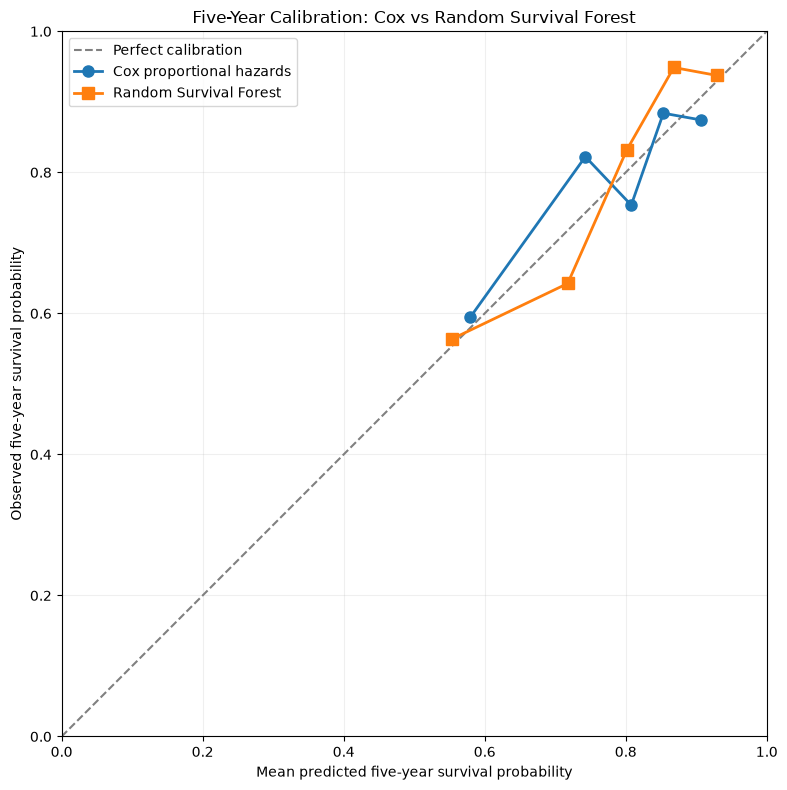

In [11]:

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    linewidth=1.5,
    label="Perfect calibration"
)

ax.plot(
    cox_calibration_5groups["Mean_Predicted_Survival"],
    cox_calibration_5groups["Observed_KM_Survival"],
    marker="o",
    markersize=8,
    linewidth=2,
    label="Cox proportional hazards"
)

ax.plot(
    rsf_calibration_5groups["Mean_Predicted_Survival"],
    rsf_calibration_5groups["Observed_KM_Survival"],
    marker="s",
    markersize=8,
    linewidth=2,
    label="Random Survival Forest"
)

ax.set_xlabel("Mean predicted five-year survival probability")
ax.set_ylabel("Observed five-year survival probability")
ax.set_title("Five-Year Calibration: Cox vs Random Survival Forest")

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal", adjustable="box")
ax.grid(alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

In [13]:

model_comparison.to_csv(
    RESULTS_DIR / "final_model_comparison.csv",
    index=False
)

combined_calibration.to_csv(
    RESULTS_DIR / "final_model_calibration_5yr.csv",
    index=False
)

fig.savefig(
    RESULTS_DIR / "final_model_calibration_5yr.png",
    dpi=300,
    bbox_inches="tight"
)

print("Final model comparison results saved successfully")

print("\nSaved files:")
print("final_model_comparison.csv")
print("final_model_calibration_5yr.csv")
print("final_model_calibration_5yr.png")

Final model comparison results saved successfully

Saved files:
final_model_comparison.csv
final_model_calibration_5yr.csv
final_model_calibration_5yr.png


In [15]:

import joblib
from sksurv.metrics import concordance_index_censored

cox_model = joblib.load(
    RESULTS_DIR / "cox_predictive_model.joblib"
)

cox_test_risk = cox_model.predict_partial_hazard(
    X_test
).to_numpy().ravel()

rsf_test_risk = rsf_predictions[
    "rsf_risk_score"
].to_numpy()

test_events = y_test_df["EVENT"].astype(bool).to_numpy()
test_times = y_test_df["OS_MONTHS"].to_numpy()

cox_cindex_check = concordance_index_censored(
    test_events,
    test_times,
    cox_test_risk
)[0]

rsf_cindex_check = concordance_index_censored(
    test_events,
    test_times,
    rsf_test_risk
)[0]

print("Cox test C-index:", round(cox_cindex_check, 4))
print("RSF test C-index:", round(rsf_cindex_check, 4))

print(
    "Observed C-index difference:",
    round(rsf_cindex_check - cox_cindex_check, 4)
)

assert np.isclose(
    cox_cindex_check,
    cox_test_cindex,
    atol=0.0001
)

assert np.isclose(
    rsf_cindex_check,
    rsf_metrics["test_cindex"].iloc[0],
    atol=0.0001
)

print("Both saved C-index values verified successfully")

Cox test C-index: 0.6548
RSF test C-index: 0.6912
Observed C-index difference: 0.0364
Both saved C-index values verified successfully


In [17]:

rng = np.random.default_rng(42)

n_bootstrap = 2000
n_test = len(test_times)

bootstrap_cindex_differences = []

for _ in range(n_bootstrap):
    sample_idx = rng.choice(
        n_test,
        size=n_test,
        replace=True
    )

    sampled_events = test_events[sample_idx]
    sampled_times = test_times[sample_idx]

    if sampled_events.sum() == 0:
        continue

    try:
        cox_bootstrap_cindex = concordance_index_censored(
            sampled_events,
            sampled_times,
            cox_test_risk[sample_idx]
        )[0]

        rsf_bootstrap_cindex = concordance_index_censored(
            sampled_events,
            sampled_times,
            rsf_test_risk[sample_idx]
        )[0]

        bootstrap_cindex_differences.append(
            rsf_bootstrap_cindex - cox_bootstrap_cindex
        )

    except ValueError:
        continue

bootstrap_cindex_differences = np.asarray(
    bootstrap_cindex_differences
)

cindex_ci_lower, cindex_ci_upper = np.percentile(
    bootstrap_cindex_differences,
    [2.5, 97.5]
)

print("Successful bootstrap samples:", len(bootstrap_cindex_differences))

print(
    "Observed C-index difference:",
    round(rsf_cindex_check - cox_cindex_check, 4)
)

print(
    "95% bootstrap confidence interval:",
    f"[{cindex_ci_lower:.4f}, {cindex_ci_upper:.4f}]"
)

Successful bootstrap samples: 2000
Observed C-index difference: 0.0364
95% bootstrap confidence interval: [0.0089, 0.0655]


In [19]:

from sksurv.metrics import brier_score
from sksurv.util import Surv

y_train_df = pd.read_csv(
    PREPARED_DIR / "y_train.csv"
)

y_train_surv = Surv.from_dataframe(
    event="EVENT",
    time="OS_MONTHS",
    data=y_train_df.astype({"EVENT": bool})
)

y_test_surv = Surv.from_dataframe(
    event="EVENT",
    time="OS_MONTHS",
    data=y_test_df.astype({"EVENT": bool})
)

cox_survival_5yr = cox_predictions[
    "Predicted_5_Year_Survival"
].to_numpy()

rsf_survival_5yr = rsf_predictions[
    "rsf_survival_5yr"
].to_numpy()

_, cox_brier_check = brier_score(
    y_train_surv,
    y_test_surv,
    cox_survival_5yr.reshape(-1, 1),
    times=np.array([60.0])
)

_, rsf_brier_check = brier_score(
    y_train_surv,
    y_test_surv,
    rsf_survival_5yr.reshape(-1, 1),
    times=np.array([60.0])
)

print("Cox five-year Brier score:", round(cox_brier_check[0], 4))
print("RSF five-year Brier score:", round(rsf_brier_check[0], 4))

print(
    "Brier score difference (Cox - RSF):",
    round(cox_brier_check[0] - rsf_brier_check[0], 4)
)

assert np.isclose(
    cox_brier_check[0],
    cox_brier_5yr,
    atol=0.0001
)

assert np.isclose(
    rsf_brier_check[0],
    rsf_metrics["brier_5yr"].iloc[0],
    atol=0.0001
)

print("Both five-year Brier scores verified successfully")

Cox five-year Brier score: 0.157
RSF five-year Brier score: 0.1451
Brier score difference (Cox - RSF): 0.0119
Both five-year Brier scores verified successfully


In [21]:

rng = np.random.default_rng(42)

n_bootstrap = 2000
n_test = len(y_test_surv)

bootstrap_brier_differences = []

for _ in range(n_bootstrap):
    sample_idx = rng.choice(
        n_test,
        size=n_test,
        replace=True
    )

    sampled_outcomes = y_test_surv[sample_idx]

    _, cox_bootstrap_brier = brier_score(
        y_train_surv,
        sampled_outcomes,
        cox_survival_5yr[sample_idx].reshape(-1, 1),
        times=np.array([60.0])
    )

    _, rsf_bootstrap_brier = brier_score(
        y_train_surv,
        sampled_outcomes,
        rsf_survival_5yr[sample_idx].reshape(-1, 1),
        times=np.array([60.0])
    )

    bootstrap_brier_differences.append(
        cox_bootstrap_brier[0] - rsf_bootstrap_brier[0]
    )

bootstrap_brier_differences = np.asarray(
    bootstrap_brier_differences
)

brier_ci_lower, brier_ci_upper = np.percentile(
    bootstrap_brier_differences,
    [2.5, 97.5]
)

print(
    "Successful bootstrap samples:",
    len(bootstrap_brier_differences)
)

print(
    "Observed Brier score difference (Cox - RSF):",
    round(cox_brier_check[0] - rsf_brier_check[0], 4)
)

print(
    "95% bootstrap confidence interval:",
    f"[{brier_ci_lower:.4f}, {brier_ci_upper:.4f}]"
)

Successful bootstrap samples: 2000
Observed Brier score difference (Cox - RSF): 0.0119
95% bootstrap confidence interval: [0.0023, 0.0219]


In [23]:

bootstrap_summary = pd.DataFrame({
    "Metric": [
        "Test C-index difference (RSF - Cox)",
        "Five-year Brier difference (Cox - RSF)"
    ],
    "Observed_Difference": [
        rsf_cindex_check - cox_cindex_check,
        cox_brier_check[0] - rsf_brier_check[0]
    ],
    "CI_Lower_95": [
        cindex_ci_lower,
        brier_ci_lower
    ],
    "CI_Upper_95": [
        cindex_ci_upper,
        brier_ci_upper
    ],
    "Bootstrap_Samples": [
        len(bootstrap_cindex_differences),
        len(bootstrap_brier_differences)
    ]
})

bootstrap_summary.to_csv(
    RESULTS_DIR / "final_bootstrap_comparison.csv",
    index=False
)

print("Bootstrap comparison saved successfully")
print(bootstrap_summary.round(4).to_string(index=False))

Bootstrap comparison saved successfully
                                Metric  Observed_Difference  CI_Lower_95  CI_Upper_95  Bootstrap_Samples
   Test C-index difference (RSF - Cox)               0.0364       0.0089       0.0655               2000
Five-year Brier difference (Cox - RSF)               0.0119       0.0023       0.0219               2000


In [25]:

research_summary = pd.DataFrame([{
    "Dataset": "METABRIC",
    "Outcome": "Overall survival",
    "Training_Patients": len(y_train_df),
    "Test_Patients": len(y_test_df),
    "Prediction_Horizon_Months": 60,
    "Cox_Test_C_Index": cox_cindex_check,
    "RSF_Test_C_Index": rsf_cindex_check,
    "C_Index_Difference_RSF_Minus_Cox": rsf_cindex_check - cox_cindex_check,
    "C_Index_Difference_CI_Lower": cindex_ci_lower,
    "C_Index_Difference_CI_Upper": cindex_ci_upper,
    "Cox_Five_Year_Brier": cox_brier_check[0],
    "RSF_Five_Year_Brier": rsf_brier_check[0],
    "Brier_Difference_Cox_Minus_RSF": cox_brier_check[0] - rsf_brier_check[0],
    "Brier_Difference_CI_Lower": brier_ci_lower,
    "Brier_Difference_CI_Upper": brier_ci_upper,
    "Bootstrap_Iterations": 2000
}])

research_summary.to_csv(
    RESULTS_DIR / "final_research_summary.csv",
    index=False
)

print("Final research summary saved successfully")
print(research_summary.T.to_string(header=False))

Final research summary saved successfully
Dataset                                   METABRIC
Outcome                           Overall survival
Training_Patients                             1583
Test_Patients                                  397
Prediction_Horizon_Months                       60
Cox_Test_C_Index                          0.654836
RSF_Test_C_Index                          0.691247
C_Index_Difference_RSF_Minus_Cox          0.036411
C_Index_Difference_CI_Lower                 0.0089
C_Index_Difference_CI_Upper               0.065543
Cox_Five_Year_Brier                       0.156995
RSF_Five_Year_Brier                       0.145089
Brier_Difference_Cox_Minus_RSF            0.011906
Brier_Difference_CI_Lower                 0.002323
Brier_Difference_CI_Upper                 0.021906
Bootstrap_Iterations                          2000
